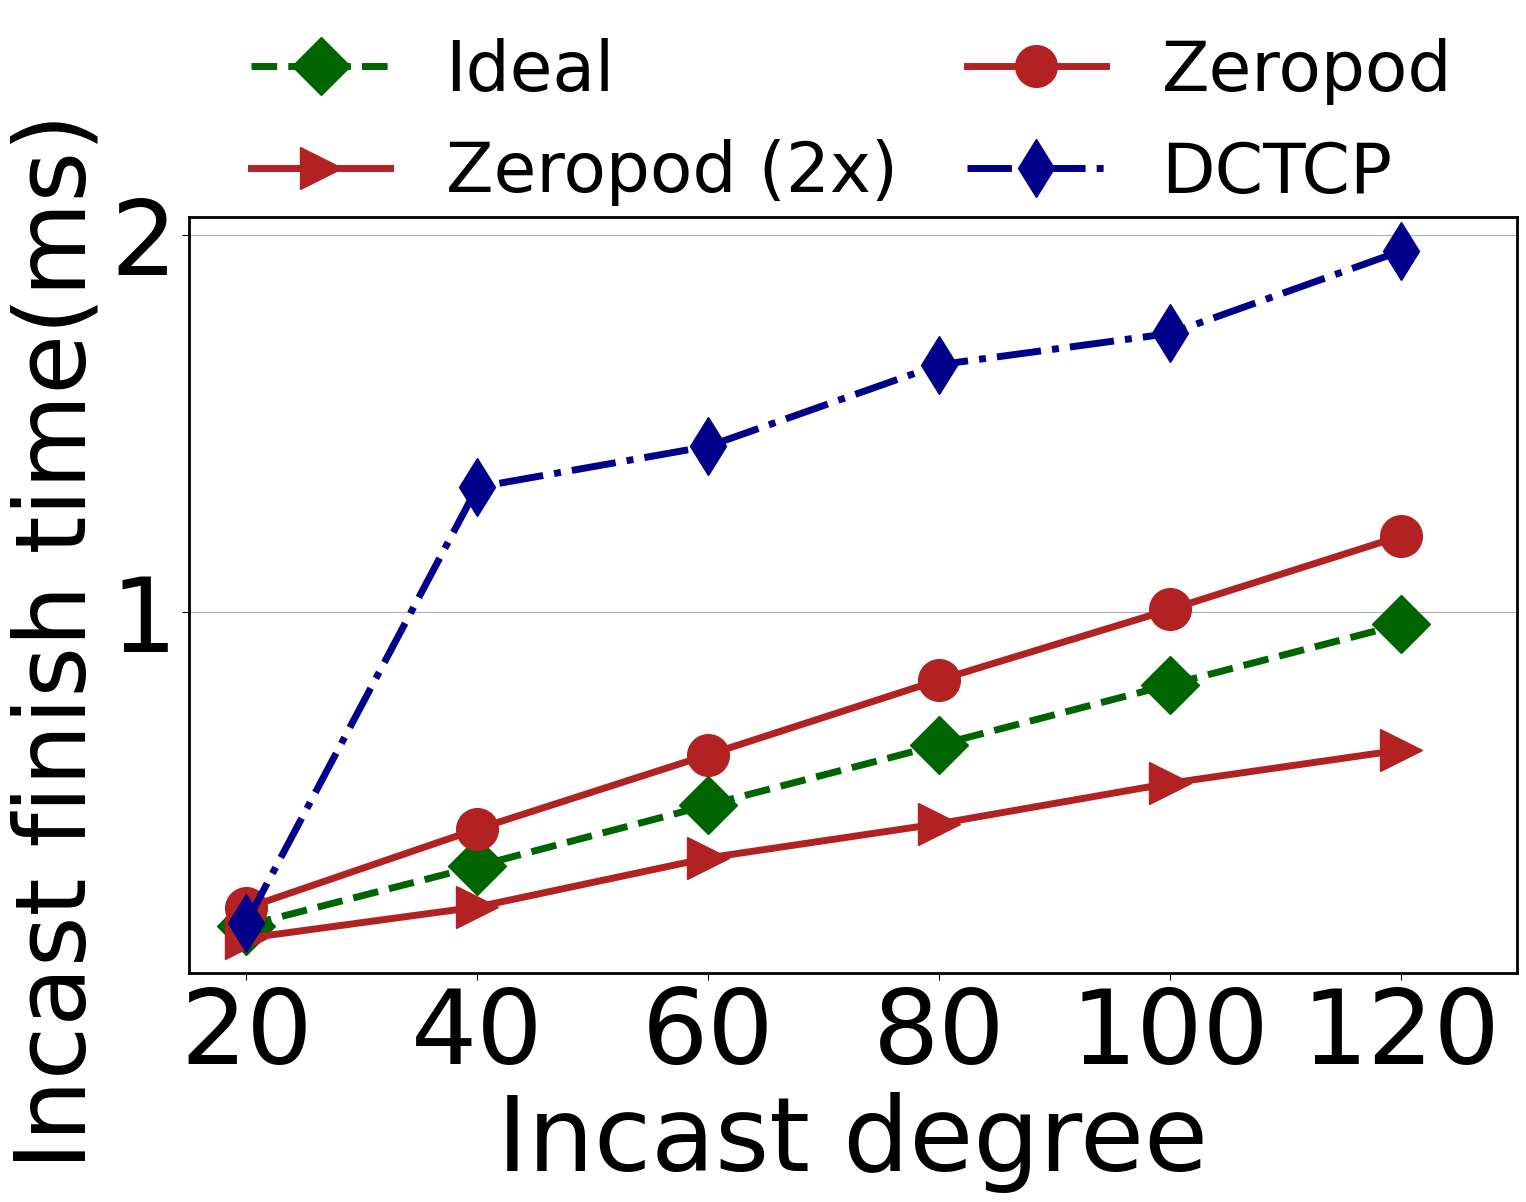

In [36]:
from matplotlib import pyplot as plt
# from brokenaxes import brokenaxes
import numpy as np
import os
import sys
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter

my_figsize = [16, 12]
my_fontsize = 75
WIDTH = 0.05  # the width of the lines
SHORT = 100001 # 100KB
LONG = 1000000 # 1000KB
METRICS = ['FCT', 'GOODPUT']

os.chdir(sys.path[0])
os.chdir('./')

SCHEMES = [
    "../../Ideal/DATA/NSDI25/Multipods/incast",
    "../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/incast/ppt_32_bppn_320_topk_16",
    "../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/2x/incast/ppt_32_bppn_320_topk_16",
    "../../ESN/DATA/NSDI25/multipods/7-cores/incast", 
    ]
workloads = ["incast_20", "incast_40", "incast_60", "incast_80", "incast_100", "incast_120"]
incast_degree = [20, 40, 60, 80, 100, 120]

DATA_DIR_TEMP = '{scheme}/DATA_zeropod_{workload}/'

data = {}
for scheme in SCHEMES:
    data[scheme] = {}
    for workload in workloads:
        data[scheme][workload] = {}
    
for scheme in SCHEMES:
    for workload in workloads:
        dir_path = DATA_DIR_TEMP.format(scheme=scheme, workload=workload)
        data[scheme][workload]['PATH'] = dir_path
        for metric in METRICS:
            data_path = dir_path + metric + '.txt'
            data[scheme][workload][metric] = np.loadtxt(data_path)

WIDTH = 0.05
def incast_finish_time():
    results = {}
    for i, scheme in enumerate(SCHEMES):
        results[scheme] = []
        for workload in workloads:
            incast_fct = data[scheme][workload]['FCT'][:, 7] # fct
            # print(len(incast_fct))
            incast_finish_time = max(incast_fct)
            results[scheme].append(incast_finish_time*1e3)
    



    fig, ax = plt.subplots(figsize=my_figsize)
    # plt.subplots_adjust(left=0.10, right=0.96, bottom=0.15, top=0.9)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['top'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)
    ax.spines['right'].set_linewidth(2.0)
    
    lines = []
    for i, scheme in enumerate(SCHEMES):
        line, = ax.plot(incast_degree, results[SCHEMES[i]], color =colors[i], marker =markers[i], markersize=30, linestyle=linestyles[i], linewidth=5, label = labels[i])
        lines.append(line)
    # print(results)
    # ax.set_title('Accelerate by adding line rate', fontsize=my_fontsize)
    # ax.set_ylabel('Goodput\n(normalized)', fontsize=my_fontsize)
    ax.set_ylabel('    Incast finish time(ms)       ', fontsize=my_fontsize-5)
    # ax.set_xticks(x_tick)
    # ax.set_xlabel("Incast Degree", fontsize=my_fontsize)
    ax.set_xlabel("Incast degree", fontsize=my_fontsize)
    # ax.set_xticklabels(labels, fontsize=my_fontsize)
    ax.legend(ncol=1, loc = "upper left", fontsize=my_fontsize-20, framealpha=0.3)
    ax.tick_params(axis='both', which='both', length=5, labelsize=my_fontsize)
    ax.set_xticks([0, 20, 40, 60, 80, 100, 120])
    # ax.legend(ncol=1, loc = "upper left", fontsize=my_fontsize-5, handlelength = 1.5, borderpad = 0.2,  labelspacing = 0.3, columnspacing = 1.0)

    # plt.xticks(fontsize=my_fontsize-5)
    ax.tick_params(axis='both', which='both', length=5)
    plt.xlim((15, 130))
    # plt.yticks(np.arange(-1,1.01,0.2), [1.0, 0.8, 0.6, 0.4, 0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    # plt.yticks(np.arange(0,1.01,0.2))
    ax.grid(axis="y")
    
    # plt.yticks(fontsize=my_fontsize-5)
    plt.subplots_adjust(left=0.16, right=0.99, bottom=0.2, top=0.83)
    lines = [lines[0], lines[2], lines[1], lines[3]]
    reordered_labels = [labels[0], labels[2], labels[1], labels[3]]
    ax.legend(lines, reordered_labels, ncol=2, loc = "upper left", bbox_to_anchor=(0, 1.32), fontsize=my_fontsize-25, framealpha=0, columnspacing=1)
    # ax.legend(lines, reordered_labels)
    
    
    # plt.savefig('../FIGS/microbenchmarks/incast_finish_time_multipods.pdf', bbox_inches='tight')
colors = ['darkgreen', 'firebrick', 'firebrick', 'darkblue']
linestyles = ['dashed', 'solid', 'solid', 'dashdot']
markers = ['D', 'o', '>', 'd']
labels = ['Ideal', 'Zeropod', 'Zeropod (2x)', 'DCTCP']
incast_finish_time()
plt.savefig(f"../../FIGS/NSDI25-Figures/Multi-Pods/10.1. Incast-Finish-Time-2x.pdf")

../../Ideal/DATA/NSDI25/Multipods/intrapod_allreduce [array([0.084]), array([0.404]), array([0.804]), array([2.404]), array([4.004]), array([8.004])]
../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/intrapod_allreduce/ppt_32_bppn_320_topk_16 [array([0.10565952]), array([0.45219904]), array([0.8854176]), array([2.61820992]), array([4.35104]), array([8.68306176])]
../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/2x/intrapod_allreduce/ppt_32_bppn_320_topk_16 [array([0.05947616]), array([0.23274592]), array([0.4493552]), array([1.31575136]), array([2.1821664]), array([4.34817728])]
../../ESN/DATA/NSDI25/multipods/7-cores/intrapod_allreduce [array([0.2523264]), array([0.667448]), array([1.109472]), array([2.8567376]), array([4.6074464]), array([8.9742672])]


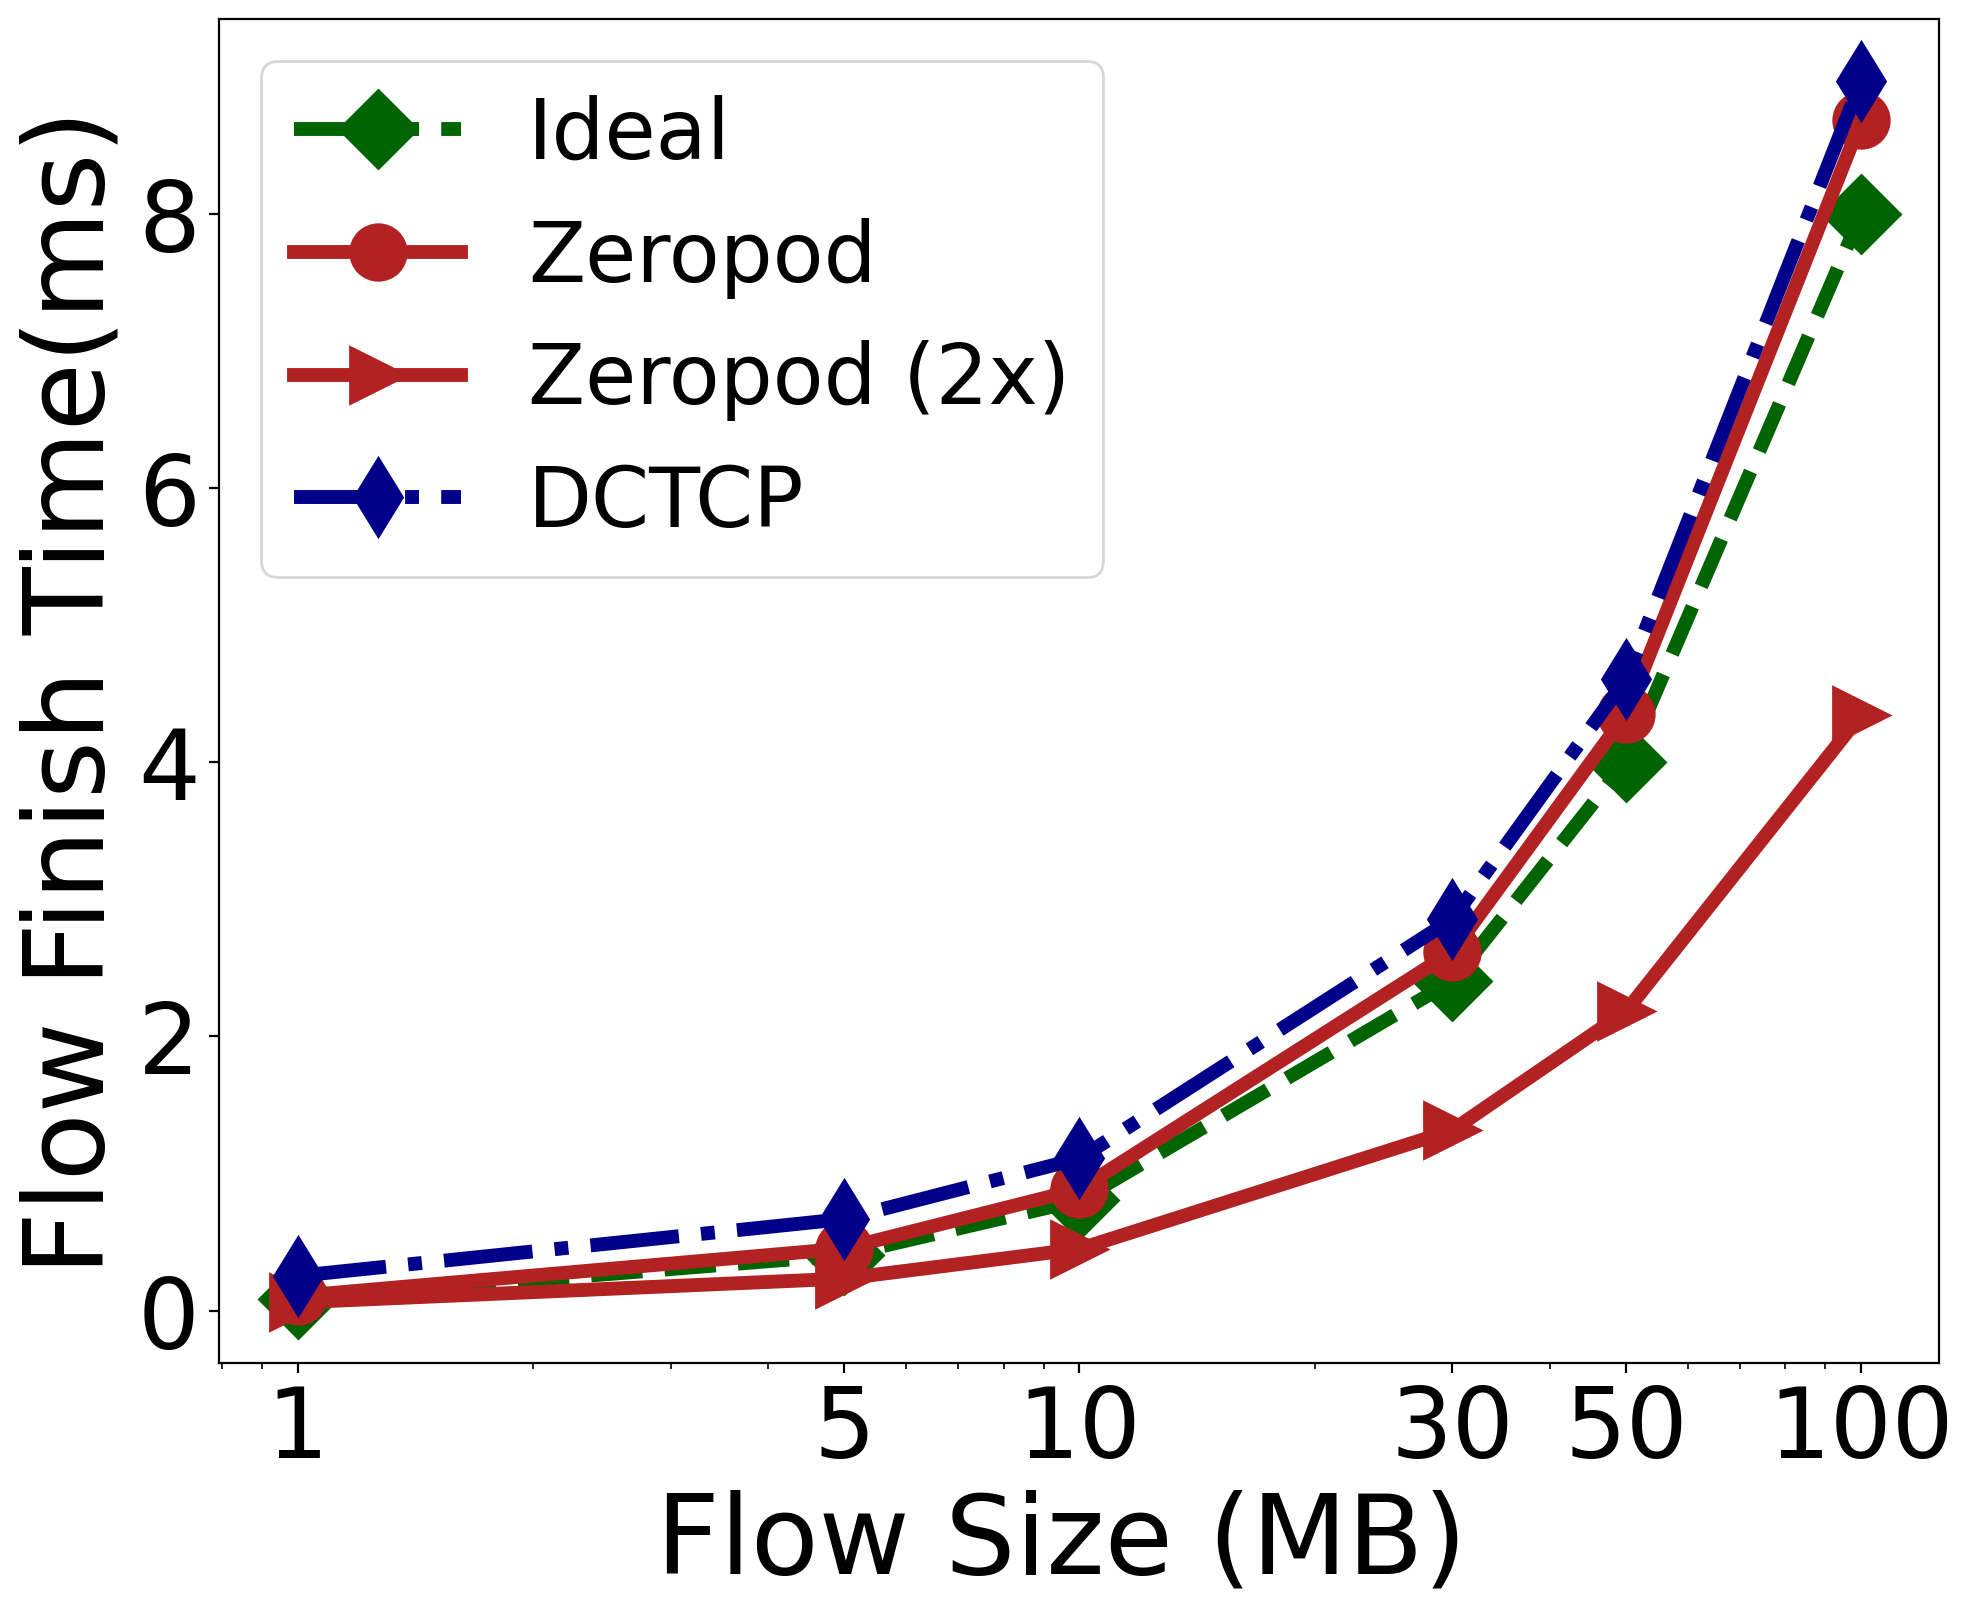

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
pattern = 'intrapod_allreduce'
schemes = ["../../Ideal/DATA/NSDI25/Multipods/{pattern}".format(pattern=pattern), 
           '../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/{pattern}/ppt_32_bppn_320_topk_16'.format(pattern=pattern), 
           '../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/2x/{pattern}/ppt_32_bppn_320_topk_16'.format(pattern=pattern), 
           '../../ESN/DATA/NSDI25/multipods/7-cores/{pattern}'.format(pattern=pattern)]
# schemes = ['dctcp/multipods_W5/permutation', 'Zeropod/multipods_W5/schedule5/permutation/ppt_32_bppn_320_topk_16']

workloads = ["permutation_size1", "permutation_size3", "permutation_size10", "permutation_size30", "permutation_size100", "permutation_size300", "permutation_size1000"]
workloads = ["allreduce_size1", "allreduce_size5", "allreduce_size10", "allreduce_size30", "allreduce_size50", "allreduce_size100"]
sizes = [1, 5, 10, 30, 50, 100]
myfontsize = 40

# load = 'Pureincast'
load = 'Permutation'
group = 1

colors = ['darkgreen', 'firebrick', 'firebrick', 'darkblue']
linestyles = ['dashed', 'solid', 'solid', 'dashdot']
markers = ['D', 'o', '>', 'd']
labels = ['Ideal', 'Zeropod', 'Zeropod (2x)', 'DCTCP']
# data = np.zeros([2 * group, len(workloads)], dtype = float) 
plt.figure(figsize=(10, 8), dpi=200)

for i, scheme in enumerate(schemes): 
    finish_time = []
    for j, workload in enumerate(workloads):
    
        dir_name = scheme + "/DATA_zeropod_" + workload
        # file_name = dir_name + "/GOODPUT.txt"
        # data[i][j] = np.loadtxt(file_name, usecols=(1,))[73]
        file_name = dir_name + "/FCT.txt"
        fct = np.loadtxt(file_name)
        # print(tmp[4:5, :])
        # data[i][j] = np.mean(8*tmp[:, 4:5] / tmp[:,7:8]) / 1e9
        finish_time.append(max(fct[:, 7:8]) * 1e3)
    print(scheme, finish_time)
    plt.plot(sizes, finish_time, color = colors[i], marker = markers[i], markersize=20, linestyle = linestyles[i], linewidth=5, label = labels[i])
    plt.xlabel("Flow Size (MB) ", fontsize=myfontsize)
    plt.ylabel(r"Flow Finish Time(ms)", fontsize=myfontsize) 
    # plt.ylabel(r"All-to-all finish time(ms)", fontsize=myfontsize) 
    plt.xscale('log')
    plt.xticks([1, 5, 10, 30, 50, 100], (1, 5, 10, 30, 50, 100), fontsize=myfontsize-5)       
    plt.yticks(fontsize=myfontsize-5)
    plt.grid(axis='y')
    plt.legend(loc = 'upper left', fontsize=myfontsize-10)   
            
plt.subplots_adjust(left=0.13, right=0.99, bottom=0.15, top=0.99)
plt.savefig(f"../../FIGS/NSDI25-Figures/Multi-Pods/10.1. Intra-Pod-AllReduce-Finish-Time-2x.pdf")


../../Ideal/DATA/NSDI25/Multipods/interrack_allreduce [array([0.086]), array([0.406]), array([0.806]), array([2.406]), array([4.006]), array([8.006])]
../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/interrack_allreduce/ppt_32_bppn_320_topk_16 [array([0.15808704]), array([0.60088896]), array([1.17437504]), array([3.43859776]), array([5.69421504]), array([11.35668032])]
../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/2x/interrack_allreduce/ppt_32_bppn_320_topk_16 [array([0.0913664]), array([0.31778144]), array([0.60026592]), array([1.75646496]), array([2.89066144]), array([5.70344032])]
../../ESN/DATA/NSDI25/multipods/7-cores/interrack_allreduce [array([0.374072]), array([0.94792]), array([1.4162256]), array([3.1591712]), array([4.9009264]), array([9.241744])]


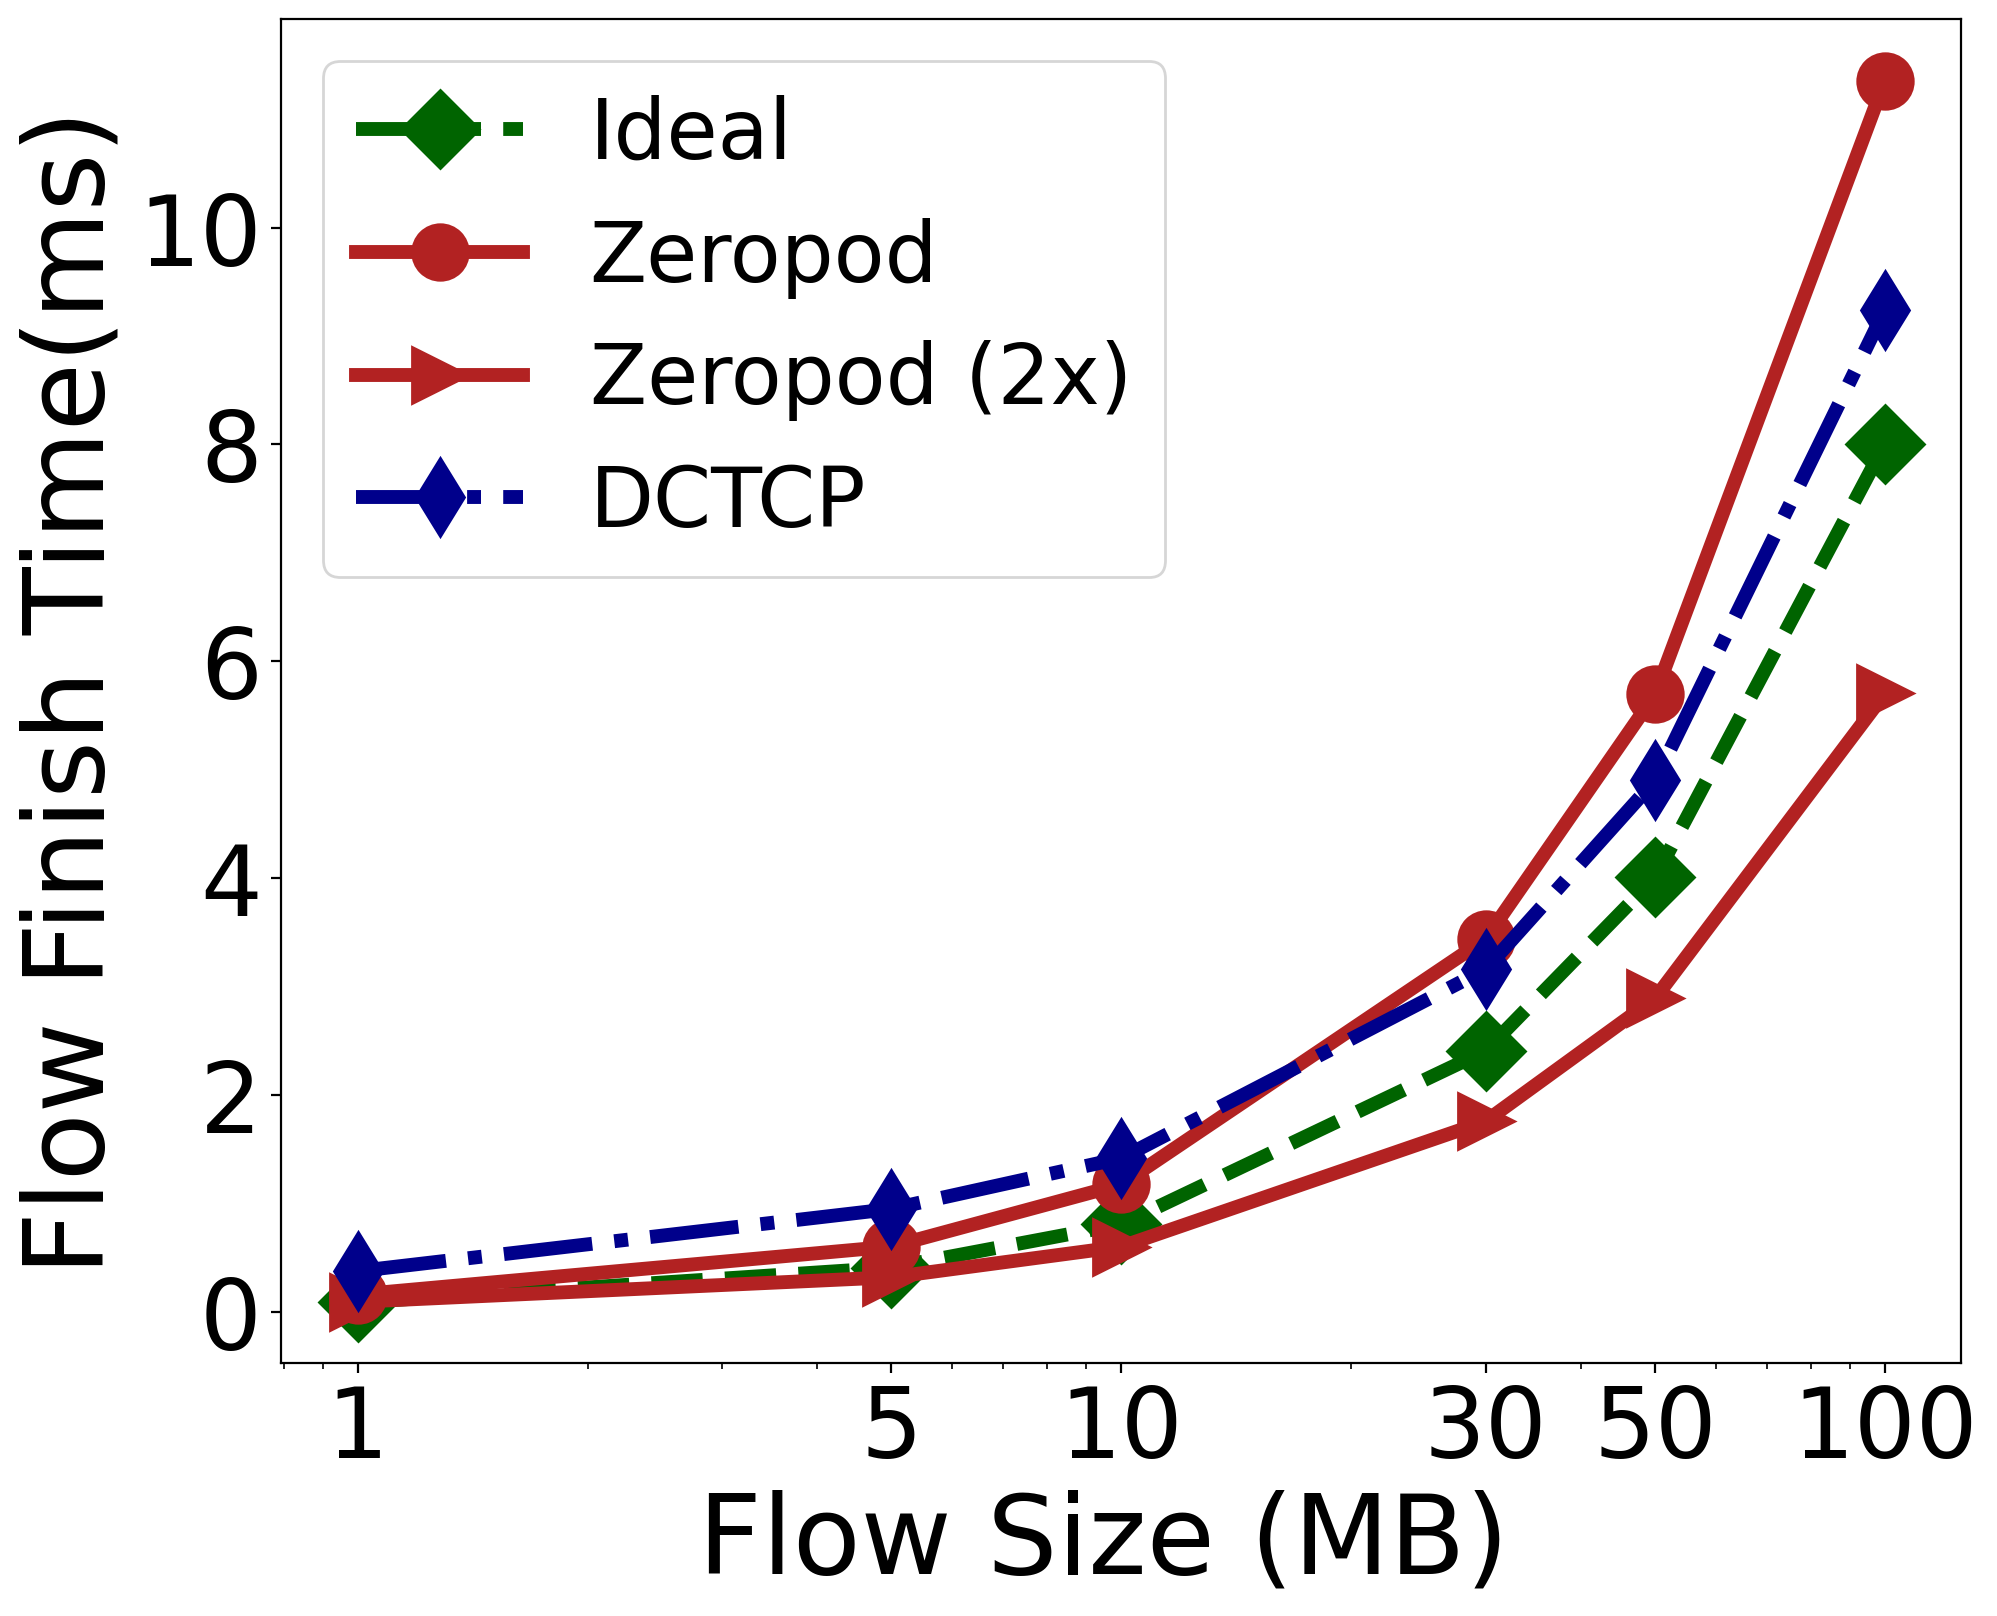

In [15]:
import numpy as np
from matplotlib import pyplot as plt
pattern = 'interrack_allreduce'
schemes = ["../../Ideal/DATA/NSDI25/Multipods/{pattern}".format(pattern=pattern), 
           '../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/{pattern}/ppt_32_bppn_320_topk_16'.format(pattern=pattern), 
           '../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/2x/{pattern}/ppt_32_bppn_320_topk_16'.format(pattern=pattern), 
           '../../ESN/DATA/NSDI25/multipods/7-cores/{pattern}'.format(pattern=pattern)]
# schemes = ['dctcp/multipods_W5/permutation', 'Zeropod/multipods_W5/schedule5/permutation/ppt_32_bppn_320_topk_16']

workloads = ["permutation_size1", "permutation_size3", "permutation_size10", "permutation_size30", "permutation_size100", "permutation_size300", "permutation_size1000"]
workloads = ["allreduce_size1", "allreduce_size5", "allreduce_size10", "allreduce_size30", "allreduce_size50", "allreduce_size100"]
sizes = [1, 5, 10, 30, 50, 100]
myfontsize = 40

# load = 'Pureincast'
load = 'Permutation'
group = 1
colors = ['darkgreen', 'firebrick', 'firebrick', 'darkblue']
linestyles = ['dashed', 'solid', 'solid', 'dashdot']
markers = ['D', 'o', '>', 'd']
labels = ['Ideal', 'Zeropod', 'Zeropod (2x)', 'DCTCP']
# data = np.zeros([2 * group, len(workloads)], dtype = float) 
plt.figure(figsize=(10, 8), dpi=200)

for i, scheme in enumerate(schemes): 
    finish_time = []
    for j, workload in enumerate(workloads):
    
        dir_name = scheme + "/DATA_zeropod_" + workload
        # file_name = dir_name + "/GOODPUT.txt"
        # data[i][j] = np.loadtxt(file_name, usecols=(1,))[73]
        file_name = dir_name + "/FCT.txt"
        fct = np.loadtxt(file_name)
        # print(tmp[4:5, :])
        # data[i][j] = np.mean(8*tmp[:, 4:5] / tmp[:,7:8]) / 1e9
        finish_time.append(max(fct[:, 7:8]) * 1e3)
    
    print(scheme, finish_time)
    plt.plot(sizes, finish_time, color = colors[i], marker = markers[i], markersize=20, linestyle = linestyles[i], linewidth=5, label = labels[i])
    plt.xlabel("Flow Size (MB) ", fontsize=myfontsize)
    plt.ylabel(r"Flow Finish Time(ms)", fontsize=myfontsize) 
    # plt.ylabel(r"All-to-all finish time(ms)", fontsize=myfontsize) 
    plt.xscale('log')
    plt.xticks([1, 5, 10, 30, 50, 100], (1, 5, 10, 30, 50, 100), fontsize=myfontsize-5)       
    plt.yticks(fontsize=myfontsize-5)
    plt.grid(axis='y')
    plt.legend(loc = 'upper left', fontsize=myfontsize-10)     
plt.subplots_adjust(left=0.15, right=0.99, bottom=0.15, top=0.99)
plt.savefig(f"../../FIGS/NSDI25-Figures/Multi-Pods/10.1. Inter-Rack-AllReduce-Finish-Time-2x.pdf")



../../Ideal/DATA/NSDI25/Multipods/whole_net_allreduce [array([0.086]), array([0.406]), array([0.806]), array([2.406]), array([4.006]), array([8.006])]
../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/whole_net_allreduce/ppt_32_bppn_320_topk_16 [array([0.19925312]), array([0.794032]), array([1.53786048]), array([4.41664704]), array([7.3493312]), array([14.58182976])]
../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/2x/whole_net_allreduce/ppt_32_bppn_320_topk_16 [array([0.11195104]), array([0.40792096]), array([0.76770304]), array([2.21496992]), array([3.70828288]), array([7.30605632])]
../../ESN/DATA/NSDI25/multipods/7-cores/whole_net_allreduce [array([0.3650976]), array([0.9454784]), array([1.4091904]), array([3.17376]), array([4.9490128]), array([9.3240384])]


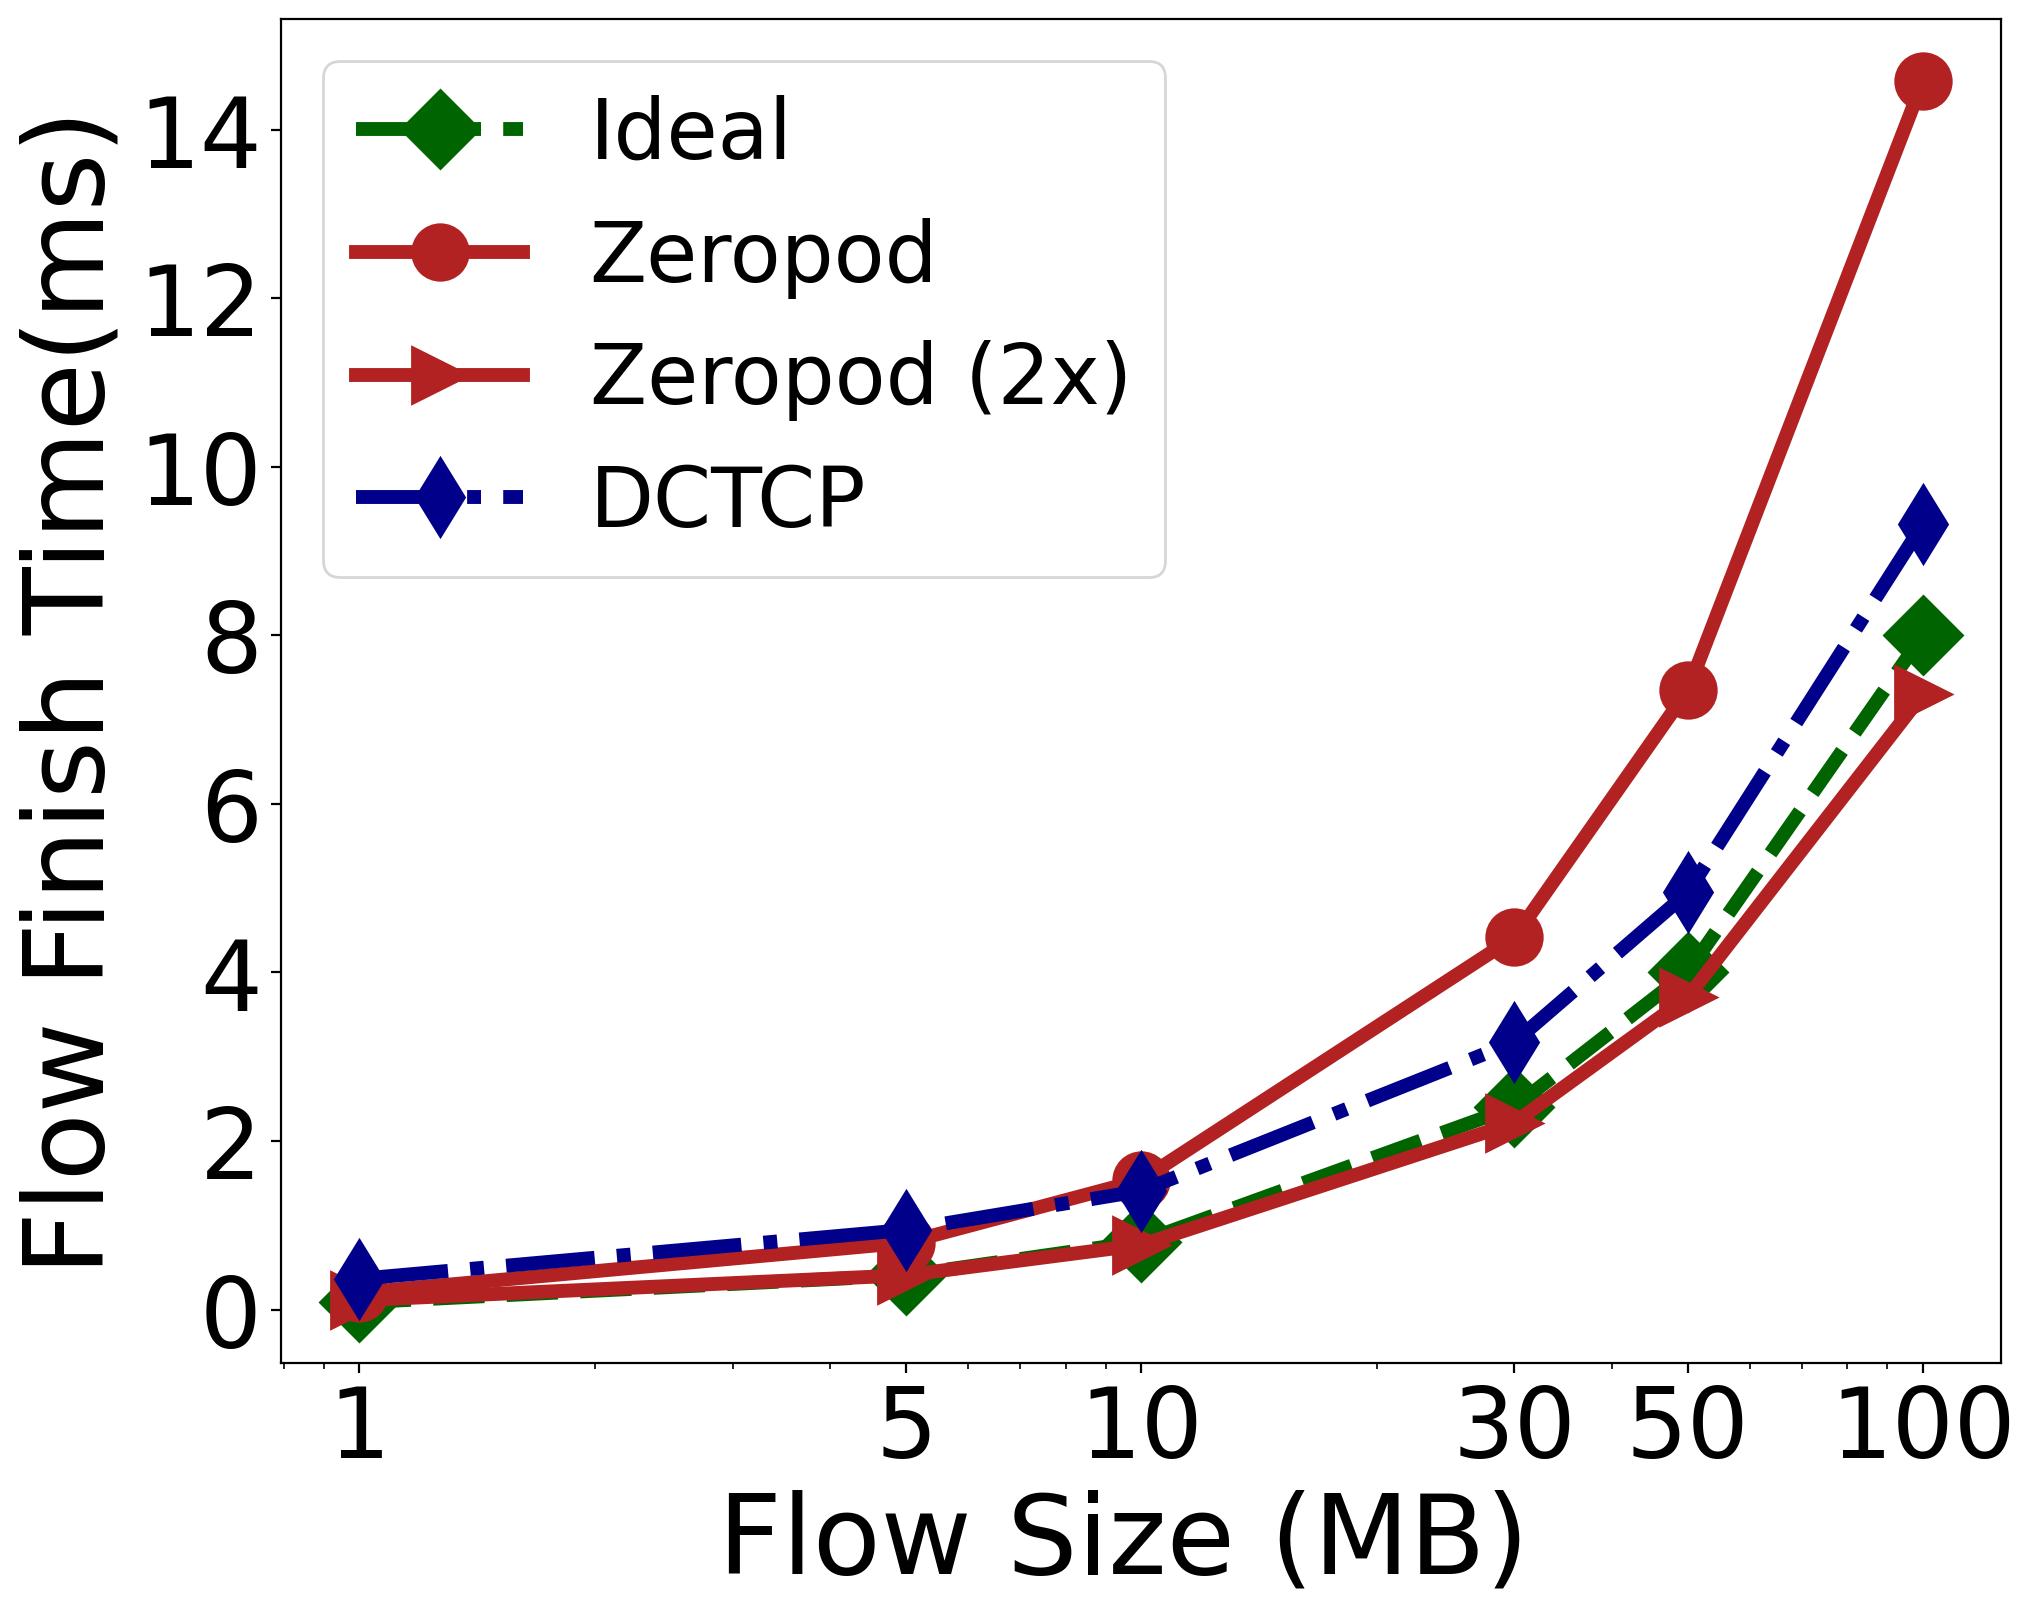

In [16]:
import numpy as np
from matplotlib import pyplot as plt
pattern = 'whole_net_allreduce'
schemes = ["../../Ideal/DATA/NSDI25/Multipods/{pattern}".format(pattern=pattern), 
           '../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/{pattern}/ppt_32_bppn_320_topk_16'.format(pattern=pattern), 
           '../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/2x/{pattern}/ppt_32_bppn_320_topk_16'.format(pattern=pattern), 
           '../../ESN/DATA/NSDI25/multipods/7-cores/{pattern}'.format(pattern=pattern)]
# schemes = ['dctcp/multipods_W5/permutation', 'Zeropod/multipods_W5/schedule5/permutation/ppt_32_bppn_320_topk_16']

workloads = ["permutation_size1", "permutation_size3", "permutation_size10", "permutation_size30", "permutation_size100", "permutation_size300", "permutation_size1000"]
workloads = ["allreduce_size1", "allreduce_size5", "allreduce_size10", "allreduce_size30", "allreduce_size50", "allreduce_size100"]
sizes = [1, 5, 10, 30, 50, 100]
myfontsize = 40

# load = 'Pureincast'
load = 'Permutation'
group = 1
colors = ['darkgreen', 'firebrick', 'firebrick', 'darkblue']
linestyles = ['dashed', 'solid', 'solid', 'dashdot']
markers = ['D', 'o', '>', 'd']
labels = ['Ideal', 'Zeropod', 'Zeropod (2x)', 'DCTCP']
# data = np.zeros([2 * group, len(workloads)], dtype = float) 
plt.figure(figsize=(10, 8), dpi=200)

for i, scheme in enumerate(schemes): 
    finish_time = []
    for j, workload in enumerate(workloads):
    
        dir_name = scheme + "/DATA_zeropod_" + workload
        # file_name = dir_name + "/GOODPUT.txt"
        # data[i][j] = np.loadtxt(file_name, usecols=(1,))[73]
        file_name = dir_name + "/FCT.txt"
        fct = np.loadtxt(file_name)
        # print(tmp[4:5, :])
        # data[i][j] = np.mean(8*tmp[:, 4:5] / tmp[:,7:8]) / 1e9
        finish_time.append(max(fct[:, 7:8]) * 1e3)

    print(scheme, finish_time)
    plt.plot(sizes, finish_time, color = colors[i], marker = markers[i], markersize=20, linestyle = linestyles[i], linewidth=5, label = labels[i])
    plt.xlabel("Flow Size (MB) ", fontsize=myfontsize)
    plt.ylabel(r"Flow Finish Time(ms)", fontsize=myfontsize) 
    # plt.ylabel(r"All-to-all finish time(ms)", fontsize=myfontsize) 
    plt.xscale('log')
    plt.xticks([1, 5, 10, 30, 50, 100], (1, 5, 10, 30, 50, 100), fontsize=myfontsize-5)       
    plt.yticks(fontsize=myfontsize-5)
    plt.grid(axis='y')
    plt.legend(loc = 'upper left', fontsize=myfontsize-10)     

plt.subplots_adjust(left=0.13, right=0.99, bottom=0.15, top=0.99)
plt.savefig(f"../../FIGS/NSDI25-Figures/Multi-Pods/10.1. All-Nodes-AllReduce-Finish-Time-2x.pdf")

../../Ideal/DATA/NSDI25/Multipods/intrapod_alltoall [array([1.444]), array([7.204]), array([14.404]), array([43.204]), array([72.004]), array([144.004])]
../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/intrapod_alltoall/ppt_32_bppn_320_topk_16 [array([1.68558528]), array([7.83938112]), array([16.49587904]), array([48.11524224]), array([82.1336384]), array([155.97955456])]
../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/2x/intrapod_alltoall/ppt_32_bppn_320_topk_16 [array([0.81679008]), array([4.04912384]), array([8.07146784]), array([24.72079552]), array([39.1535648]), array([78.00068224])]
../../ESN/DATA/NSDI25/multipods/7-cores/intrapod_alltoall [array([1.5522512]), array([7.3748224]), array([14.6935152]), array([43.74892959]), array([72.78089598]), array([146.43076477])]


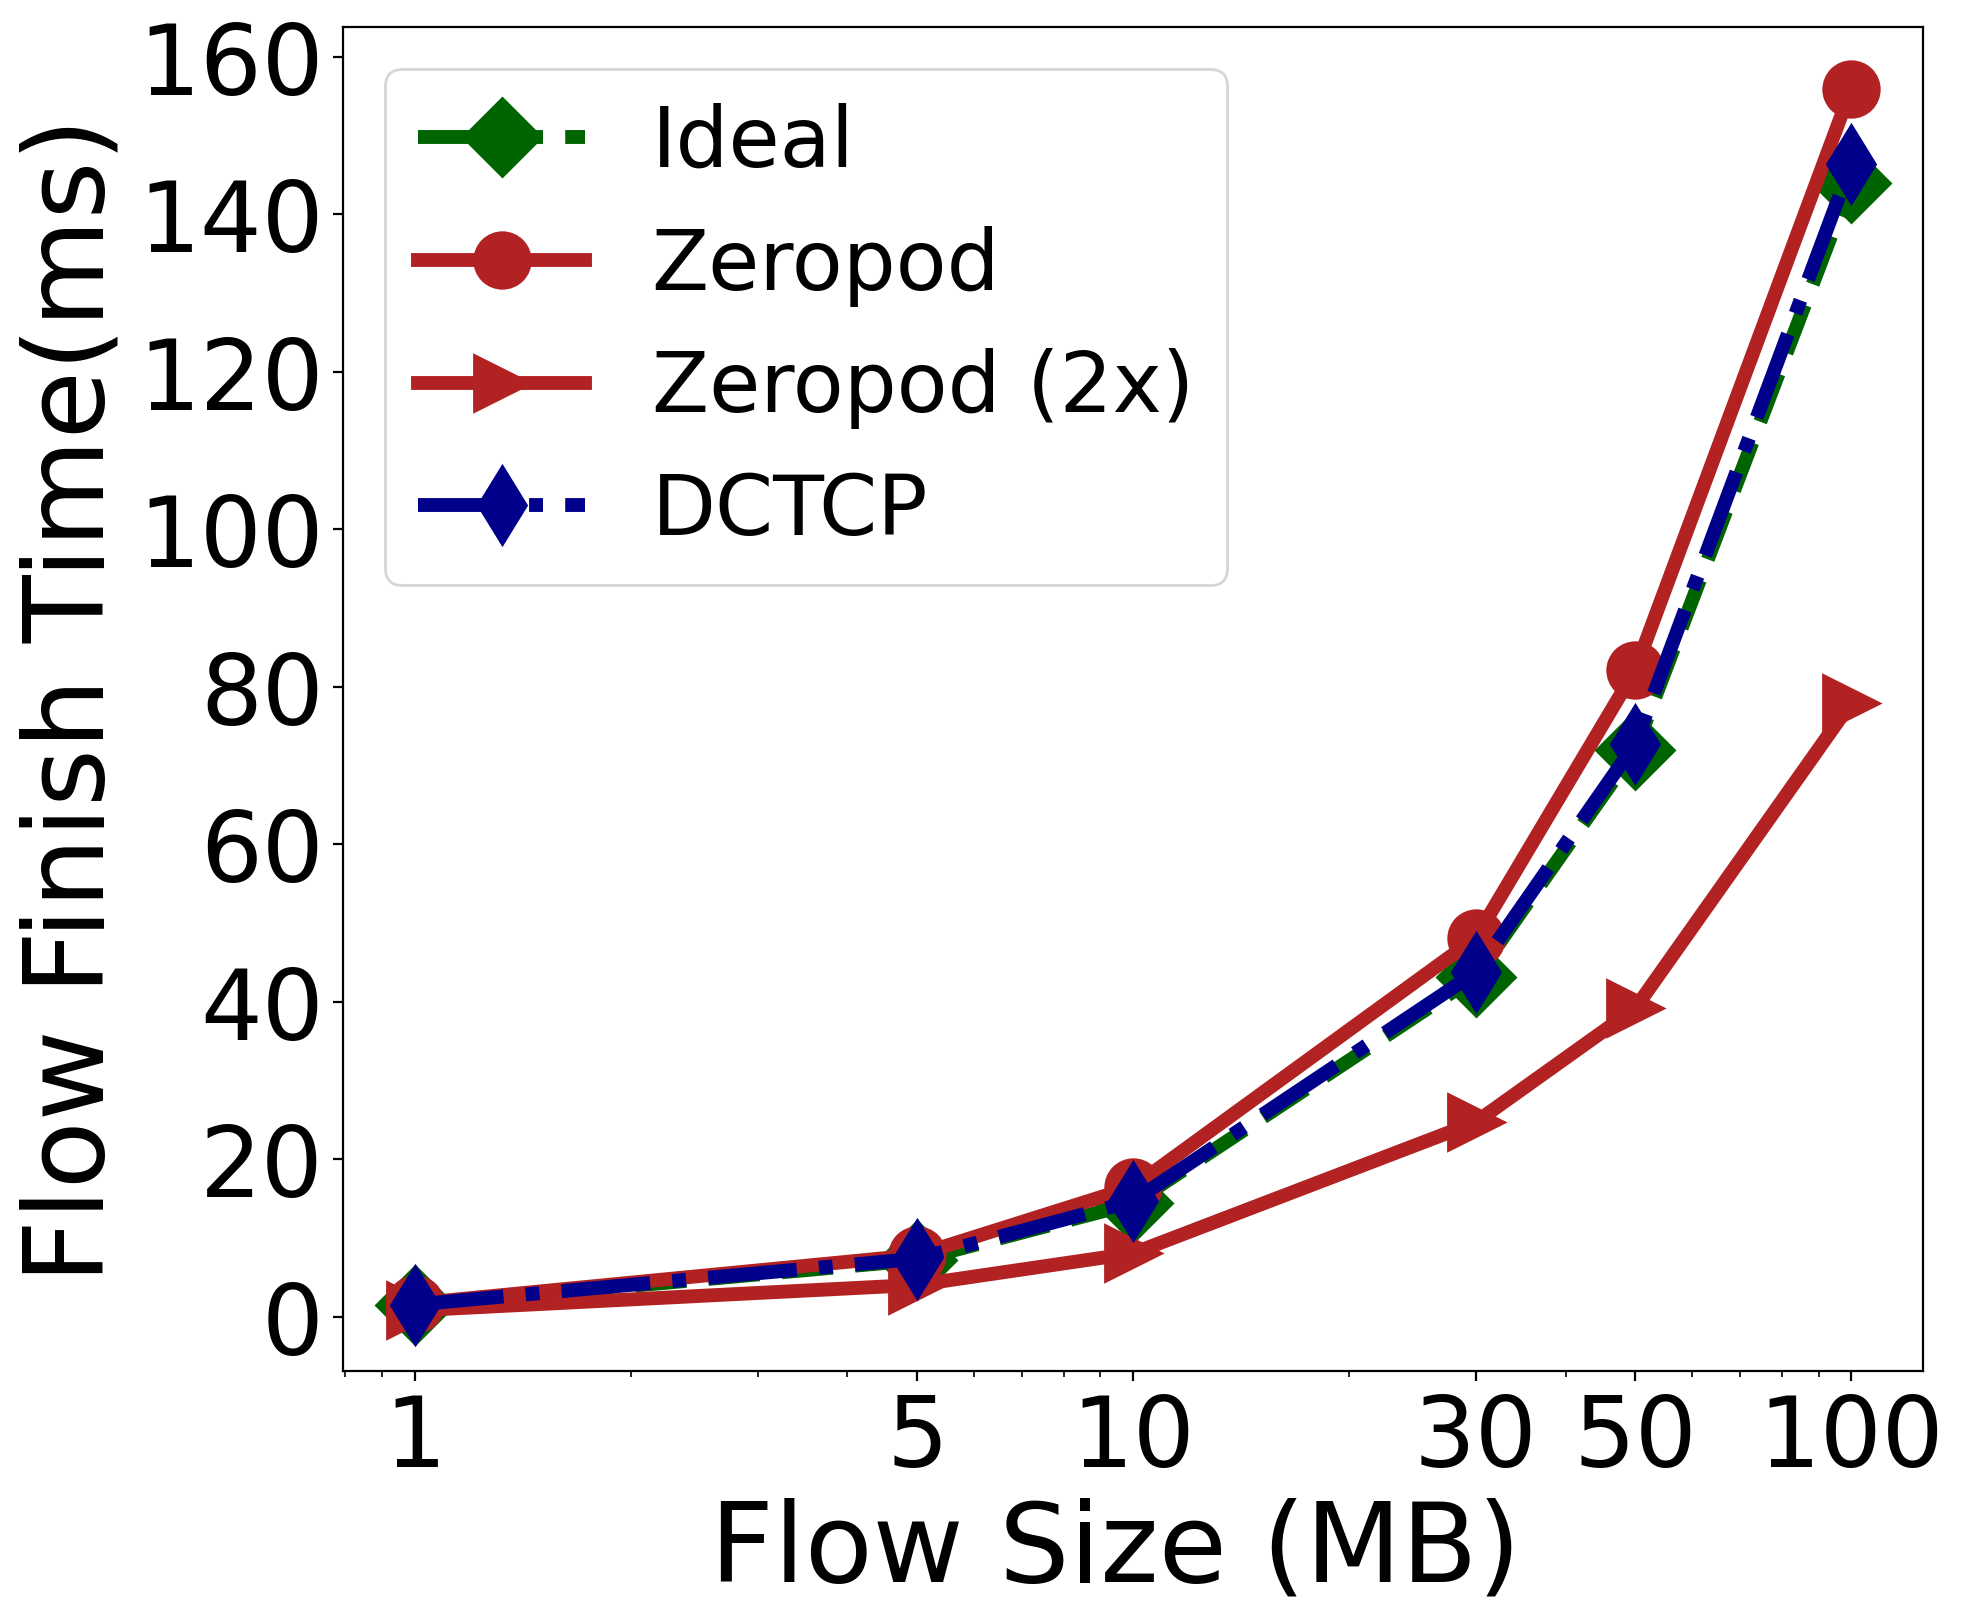

In [17]:
import numpy as np
from matplotlib import pyplot as plt
pattern = 'intrapod_alltoall'
schemes = ["../../Ideal/DATA/NSDI25/Multipods/{pattern}".format(pattern=pattern), 
           '../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/{pattern}/ppt_32_bppn_320_topk_16'.format(pattern=pattern), 
           '../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/2x/{pattern}/ppt_32_bppn_320_topk_16'.format(pattern=pattern), 
           '../../ESN/DATA/NSDI25/multipods/7-cores/{pattern}'.format(pattern=pattern)]
# schemes = ['dctcp/multipods_W5/permutation', 'Zeropod/multipods_W5/schedule5/permutation/ppt_32_bppn_320_topk_16']

workloads = ["permutation_size1", "permutation_size3", "permutation_size10", "permutation_size30", "permutation_size100", "permutation_size300", "permutation_size1000"]
workloads = ["allreduce_size1", "allreduce_size5", "allreduce_size10", "allreduce_size30", "allreduce_size50", "allreduce_size100"]
sizes = [1, 5, 10, 30, 50, 100]
myfontsize = 40

# load = 'Pureincast'
load = 'Permutation'
group = 1
colors = ['darkgreen', 'firebrick', 'firebrick', 'darkblue']
linestyles = ['dashed', 'solid', 'solid', 'dashdot']
markers = ['D', 'o', '>', 'd']
labels = ['Ideal', 'Zeropod', 'Zeropod (2x)', 'DCTCP']
# data = np.zeros([2 * group, len(workloads)], dtype = float) 
plt.figure(figsize=(10, 8), dpi=200)

for i, scheme in enumerate(schemes): 
    finish_time = []
    for j, workload in enumerate(workloads):
    
        dir_name = scheme + "/DATA_zeropod_" + workload
        # file_name = dir_name + "/GOODPUT.txt"
        # data[i][j] = np.loadtxt(file_name, usecols=(1,))[73]
        file_name = dir_name + "/FCT.txt"
        fct = np.loadtxt(file_name)
        # print(tmp[4:5, :])
        # data[i][j] = np.mean(8*tmp[:, 4:5] / tmp[:,7:8]) / 1e9
        finish_time.append(max(fct[:, 7:8]) * 1e3)
        
    print(scheme, finish_time)
    plt.plot(sizes, finish_time, color = colors[i], marker = markers[i], markersize=20, linestyle = linestyles[i], linewidth=5, label = labels[i])
    plt.xlabel("Flow Size (MB) ", fontsize=myfontsize)
    plt.ylabel(r"Flow Finish Time(ms)", fontsize=myfontsize) 
    # plt.ylabel(r"All-to-all finish time(ms)", fontsize=myfontsize) 
    plt.xscale('log')
    plt.xticks([1, 5, 10, 30, 50, 100], (1, 5, 10, 30, 50, 100), fontsize=myfontsize-5)       
    plt.yticks(fontsize=myfontsize-5)
    plt.grid(axis='y')
    plt.legend(loc = 'upper left', fontsize=myfontsize-10)     
            
plt.subplots_adjust(left=0.2, right=0.99, bottom=0.15, top=0.99)
plt.savefig(f"../../FIGS/NSDI25-Figures/Multi-Pods/10.1. Intra-Pod-Alltoall-Finish-Time-2x.pdf")


../../Ideal/DATA/NSDI25/Multipods/interrack_alltoall [array([2.806]), array([14.006]), array([28.006]), array([84.006]), array([140.006]), array([280.006])]
../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/interrack_alltoall/ppt_32_bppn_320_topk_16 [array([7.06689088]), array([41.77273536]), array([85.10926144]), array([258.31483328]), array([440.09856128]), array([870.48567232])]
../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/2x/interrack_alltoall/ppt_32_bppn_320_topk_16 [array([3.23054816]), array([20.8749168]), array([41.97359424]), array([130.75889376]), array([213.35011456]), array([425.72947008])]
../../ESN/DATA/NSDI25/multipods/7-cores/interrack_alltoall [array([4.0157456]), array([16.1338672]), array([31.37476639]), array([91.38500798]), array([151.63105597]), array([302.16390073])]


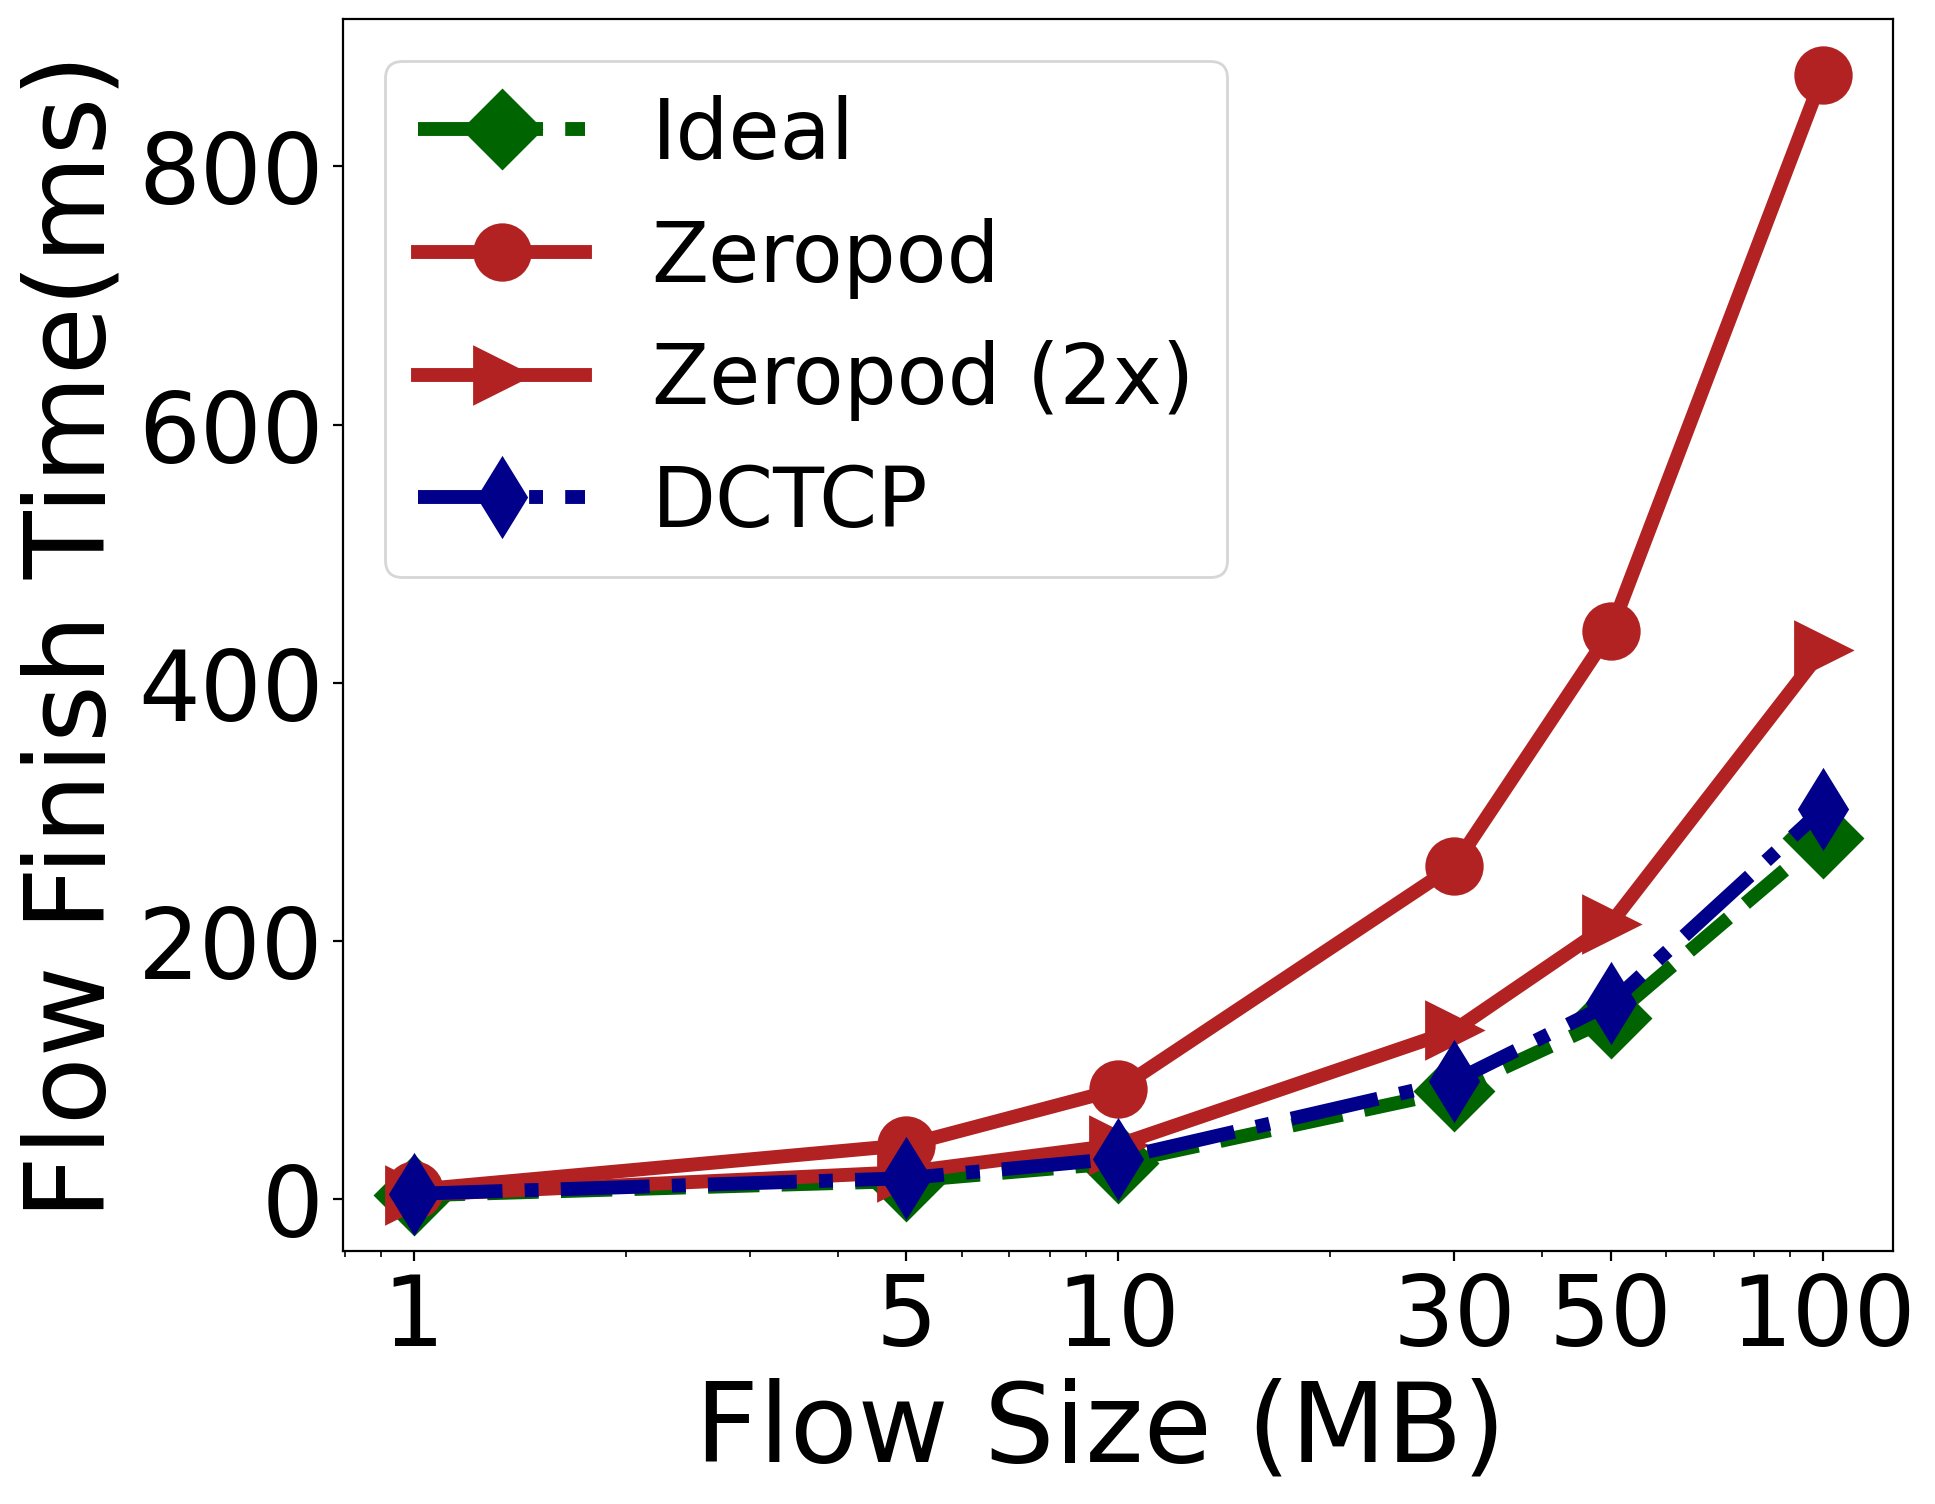

In [19]:
import numpy as np
from matplotlib import pyplot as plt
pattern = 'interrack_alltoall'
schemes = ["../../Ideal/DATA/NSDI25/Multipods/{pattern}".format(pattern=pattern), 
           '../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/{pattern}/ppt_32_bppn_320_topk_16'.format(pattern=pattern), 
           '../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/2x/{pattern}/ppt_32_bppn_320_topk_16'.format(pattern=pattern), 
           '../../ESN/DATA/NSDI25/multipods/7-cores/{pattern}'.format(pattern=pattern)]
# schemes = ['dctcp/multipods_W5/permutation', 'Zeropod/multipods_W5/schedule5/permutation/ppt_32_bppn_320_topk_16']

workloads = ["permutation_size1", "permutation_size3", "permutation_size10", "permutation_size30", "permutation_size100", "permutation_size300", "permutation_size1000"]
workloads = ["allreduce_size1", "allreduce_size5", "allreduce_size10", "allreduce_size30", "allreduce_size50", "allreduce_size100"]
sizes = [1, 5, 10, 30, 50, 100]
myfontsize = 40

# load = 'Pureincast'
load = 'Permutation'
group = 1
colors = ['darkgreen', 'firebrick', 'firebrick', 'darkblue']
linestyles = ['dashed', 'solid', 'solid', 'dashdot']
markers = ['D', 'o', '>', 'd']
labels = ['Ideal', 'Zeropod', 'Zeropod (2x)', 'DCTCP']
# data = np.zeros([2 * group, len(workloads)], dtype = float) 
plt.figure(figsize=(10, 8), dpi=200)

for i, scheme in enumerate(schemes): 
    finish_time = []
    for j, workload in enumerate(workloads):
    
        dir_name = scheme + "/DATA_zeropod_" + workload
        # file_name = dir_name + "/GOODPUT.txt"
        # data[i][j] = np.loadtxt(file_name, usecols=(1,))[73]
        file_name = dir_name + "/FCT.txt"
        fct = np.loadtxt(file_name)
        # print(tmp[4:5, :])
        # data[i][j] = np.mean(8*tmp[:, 4:5] / tmp[:,7:8]) / 1e9
        finish_time.append(max(fct[:, 7:8]) * 1e3)
        
    print(scheme, finish_time)
    plt.plot(sizes, finish_time, color = colors[i], marker = markers[i], markersize=20, linestyle = linestyles[i], linewidth=5, label = labels[i])
    plt.xlabel("Flow Size (MB) ", fontsize=myfontsize)
    plt.ylabel(r"Flow Finish Time(ms)", fontsize=myfontsize) 
    # plt.ylabel(r"All-to-all finish time(ms)", fontsize=myfontsize) 
    plt.xscale('log')
    plt.xticks([1, 5, 10, 30, 50, 100], (1, 5, 10, 30, 50, 100), fontsize=myfontsize-5)       
    plt.yticks(fontsize=myfontsize-5)
    plt.grid(axis='y')
    plt.legend(loc = 'upper left', fontsize=myfontsize-10)     
            
plt.subplots_adjust(left=0.2, right=0.99, bottom=0.15, top=0.99)
plt.savefig(f"../../FIGS/NSDI25-Figures/Multi-Pods/10.1. Interrack-Alltoall-Finish-Time-2x.pdf")
# print(data)
